# Notebook 1: Graph Foundations

Welcome to the GNN curriculum. Before we touch any neural network, we need a solid understanding of what graphs *are* and how they're represented in code. Everything in later notebooks builds on this.

**Prerequisites:** Python, NumPy, basic PyTorch familiarity

**What you'll learn:**
- What graphs are and why they matter for ML
- Key graph properties: adjacency, degree, Laplacian
- How PyTorch Geometric represents graphs
- Node and edge features

**By the end:** you'll build and analyze a small social network graph from scratch.

In [1]:
# If needed, install dependencies:
# pip install torch-geometric networkx matplotlib scikit-learn

import torch
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import defaultdict

torch.manual_seed(42)
np.random.seed(42)
print('PyTorch:', torch.__version__)
print('NetworkX:', nx.__version__)

PyTorch: 2.8.0
NetworkX: 3.2.1


---
## 1. What Is a Graph?

A **graph** G = (V, E) consists of:
- **V** — a set of *nodes* (vertices)
- **E** — a set of *edges* (connections between nodes)

Graphs appear everywhere in the real world:

| Domain | Nodes | Edges |
|--------|-------|-------|
| Social networks | Users | Friendships |
| Molecules | Atoms | Bonds |
| Citation networks | Papers | Citations |
| Road networks | Intersections | Roads |
| Knowledge graphs | Entities | Relations |

The key insight: **standard deep learning (CNNs, RNNs) assumes grid or sequence structure**. Graphs are *irregular* — each node can have a different number of neighbors, and there's no canonical ordering. GNNs are designed specifically for this.

Nodes: [0, 1, 2, 3, 4]
Edges: [(0, 1), (0, 2), (1, 2), (2, 3), (3, 4)]
Number of nodes: 5
Number of edges: 5


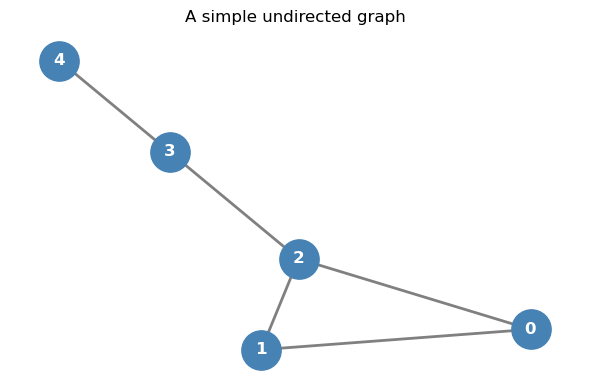

In [2]:
# Create a simple undirected graph
G = nx.Graph()

# Add nodes
G.add_nodes_from([0, 1, 2, 3, 4])

# Add edges
G.add_edges_from([
    (0, 1), (0, 2), (1, 2),   # triangle: 0-1-2
    (2, 3), (3, 4)             # chain: 2-3-4
])

print(f'Nodes: {list(G.nodes())}')
print(f'Edges: {list(G.edges())}')
print(f'Number of nodes: {G.number_of_nodes()}')
print(f'Number of edges: {G.number_of_edges()}')

fig, ax = plt.subplots(figsize=(6, 4))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='steelblue',
        node_size=800, font_color='white', font_weight='bold',
        edge_color='gray', width=2, ax=ax)
ax.set_title('A simple undirected graph')
plt.tight_layout()
plt.show()

---
## 2. Types of Graphs

| Type | Description | Example |
|------|------------|--------|
| **Undirected** | Edges have no direction | Friendships |
| **Directed (digraph)** | Edges have a direction | Twitter follows |
| **Weighted** | Edges have a numeric weight | Road distances |
| **Bipartite** | Two disjoint node sets | Users & movies |
| **Heterogeneous** | Multiple node/edge types | Knowledge graphs |

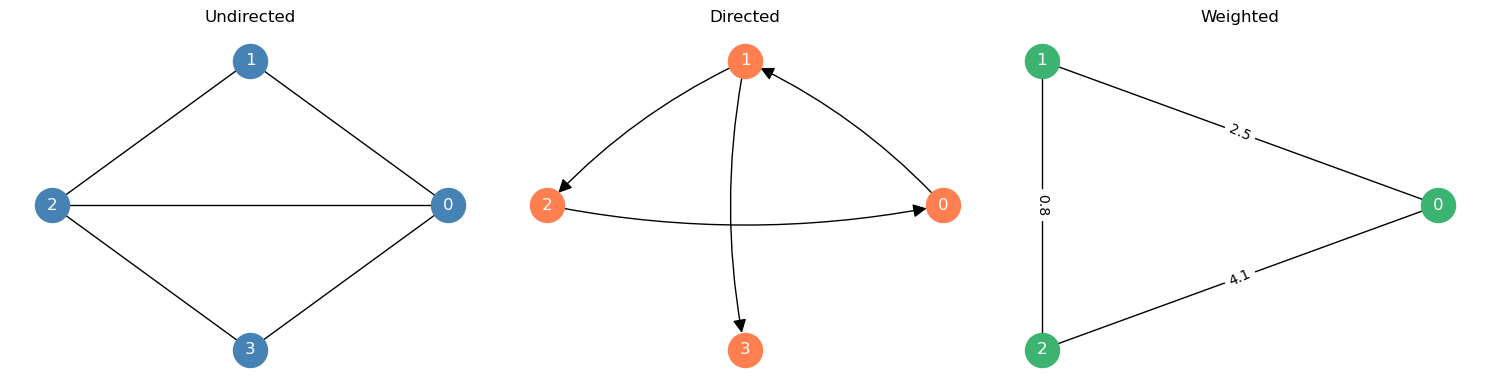

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Undirected ---
G_undirected = nx.Graph()
G_undirected.add_edges_from([(0,1),(1,2),(2,3),(3,0),(0,2)])
pos_u = nx.circular_layout(G_undirected)
nx.draw(G_undirected, pos_u, ax=axes[0], with_labels=True,
        node_color='steelblue', node_size=600, font_color='white')
axes[0].set_title('Undirected')

# --- Directed ---
G_directed = nx.DiGraph()
G_directed.add_edges_from([(0,1),(1,2),(2,0),(1,3)])
pos_d = nx.circular_layout(G_directed)
nx.draw(G_directed, pos_d, ax=axes[1], with_labels=True,
        node_color='coral', node_size=600, font_color='white',
        arrows=True, arrowsize=20, connectionstyle='arc3,rad=0.1')
axes[1].set_title('Directed')

# --- Weighted ---
G_weighted = nx.Graph()
G_weighted.add_edge(0, 1, weight=2.5)
G_weighted.add_edge(1, 2, weight=0.8)
G_weighted.add_edge(0, 2, weight=4.1)
pos_w = nx.circular_layout(G_weighted)
nx.draw(G_weighted, pos_w, ax=axes[2], with_labels=True,
        node_color='mediumseagreen', node_size=600, font_color='white')
edge_labels = nx.get_edge_attributes(G_weighted, 'weight')
nx.draw_networkx_edge_labels(G_weighted, pos_w, edge_labels=edge_labels, ax=axes[2])
axes[2].set_title('Weighted')

plt.tight_layout()
plt.show()

---
## 3. Graph Representations

There are several ways to represent a graph mathematically. GNNs rely heavily on the **adjacency matrix** and **edge list** formats.

### Adjacency Matrix A
- Shape: N x N (N = number of nodes)
- A[i][j] = 1 if there's an edge from i to j, else 0
- For undirected graphs: A is symmetric

### Edge Index (PyG format)
- Shape: 2 x E (E = number of edges)
- Row 0: source nodes, Row 1: destination nodes
- Very memory-efficient for sparse graphs

### Why edge index?
Real graphs can have millions of nodes but are *sparse* (each node connects to very few others). Storing the full N x N matrix wastes huge amounts of memory. Edge index stores only existing edges.

In [4]:
# Using our graph G from above
# Adjacency matrix
A = nx.to_numpy_array(G)
print('Adjacency Matrix A:')
print(A)
print()

# Properties from adjacency matrix
print('Degree of each node (row sums):', A.sum(axis=1))
print()

# Convert to PyG-style edge_index
edges = list(G.edges())
# For undirected: add both directions
src = [e[0] for e in edges] + [e[1] for e in edges]
dst = [e[1] for e in edges] + [e[0] for e in edges]
edge_index = torch.tensor([src, dst], dtype=torch.long)
print('Edge Index (PyG format):')
print(edge_index)
print(f'Shape: {edge_index.shape}  (2 x num_edges)')

Adjacency Matrix A:
[[0. 1. 1. 0. 0.]
 [1. 0. 1. 0. 0.]
 [1. 1. 0. 1. 0.]
 [0. 0. 1. 0. 1.]
 [0. 0. 0. 1. 0.]]

Degree of each node (row sums): [2. 2. 3. 2. 1.]

Edge Index (PyG format):
tensor([[0, 0, 1, 2, 3, 1, 2, 2, 3, 4],
        [1, 2, 2, 3, 4, 0, 0, 1, 2, 3]])
Shape: torch.Size([2, 10])  (2 x num_edges)


---
## 4. The Graph Laplacian

The **Laplacian** L = D - A is one of the most important matrices in graph theory. It appears in spectral graph theory and is the mathematical foundation of early GNN methods.

- **D**: diagonal degree matrix — D[i,i] = degree of node i
- **L**: captures the local smoothness structure of the graph
- **Normalized Laplacian**: L_sym = D^{-1/2} L D^{-1/2} = I - D^{-1/2} A D^{-1/2}

The normalized Laplacian appears directly in the GCN formula (Notebook 2).

**Eigenvalues of L:** The smallest eigenvalue is always 0. The number of zero eigenvalues = number of connected components. The largest eigenvalue tells us about graph expansion.

In [6]:
A = nx.to_numpy_array(G)
N = A.shape[0]

# Degree matrix
degrees = A.sum(axis=1)
D = np.diag(degrees)

# Unnormalized Laplacian
L = D - A

# Normalized Laplacian
D_inv_sqrt = np.diag(1.0 / np.sqrt(degrees))
L_sym = np.eye(N) - D_inv_sqrt @ A @ D_inv_sqrt

print('Degree matrix D:')
print(D)
print()
print('Unnormalized Laplacian L = D - A:')
print(np.round(L, 2))
print()
print('Normalized Laplacian L_sym:')
print(np.round(L_sym, 3))
print()

# Eigenvalue analysis
eigenvalues = np.linalg.eigvalsh(L_sym)
print('Eigenvalues of L_sym (sorted):')
print(np.round(eigenvalues, 4))
print(f'Number of zero eigenvalues (connected components): {np.sum(np.abs(eigenvalues) < 1e-10)}')

Degree matrix D:
[[2. 0. 0. 0. 0.]
 [0. 2. 0. 0. 0.]
 [0. 0. 3. 0. 0.]
 [0. 0. 0. 2. 0.]
 [0. 0. 0. 0. 1.]]

Unnormalized Laplacian L = D - A:
[[ 2. -1. -1.  0.  0.]
 [-1.  2. -1.  0.  0.]
 [-1. -1.  3. -1.  0.]
 [ 0.  0. -1.  2. -1.]
 [ 0.  0.  0. -1.  1.]]

Normalized Laplacian L_sym:
[[ 1.    -0.5   -0.408  0.     0.   ]
 [-0.5    1.    -0.408  0.     0.   ]
 [-0.408 -0.408  1.    -0.408  0.   ]
 [ 0.     0.    -0.408  1.    -0.707]
 [ 0.     0.     0.    -0.707  1.   ]]

Eigenvalues of L_sym (sorted):
[-0.      0.3459  1.2975  1.5     1.8566]
Number of zero eigenvalues (connected components): 1


---
## 5. PyTorch Geometric: The Data Object

PyG represents a graph as a `torch_geometric.data.Data` object. Think of it as a named container with these key fields:

| Field | Type | Description |
|-------|------|-------------|
| `x` | FloatTensor [N, F] | Node feature matrix |
| `edge_index` | LongTensor [2, E] | Edge connectivity |
| `edge_attr` | FloatTensor [E, D] | Edge feature matrix |
| `y` | Tensor [N] or [1] | Node or graph labels |
| `pos` | FloatTensor [N, dim] | Node positions |

This uniform interface means ALL PyG models/datasets use the same format — huge for code reusability.

In [12]:
from torch_geometric.data import Data
from torch_geometric.utils import to_networkx

# Build a small social network in PyG format
# 6 people: [Alice, Bob, Charlie, Dana, Eve, Frank]
# Features: [age_normalized, is_student]
num_nodes = 6

x = torch.tensor([
    [0.25, 1.0],  # Alice: 25 years old, student
    [0.32, 0.0],  # Bob: 32, not student
    [0.28, 1.0],  # Charlie: 28, student
    [0.45, 0.0],  # Dana: 45, not student
    [0.22, 1.0],  # Eve: 22, student
    [0.38, 0.0],  # Frank: 38, not student
], dtype=torch.float)

# Edges (undirected: include both directions)
edge_index = torch.tensor([
    [0, 1, 0, 2, 1, 3, 2, 4, 3, 5, 1, 5],  # source
    [1, 0, 2, 0, 3, 1, 4, 2, 5, 3, 5, 1],  # destination
], dtype=torch.long)

# Labels: 0=not_in_club, 1=in_club
y = torch.tensor([1, 1, 0, 0, 1, 0], dtype=torch.long)

data = Data(x=x, edge_index=edge_index, y=y)
print(data)
print()
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Number of node features: {data.num_node_features}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')

Data(x=[6, 2], edge_index=[2, 12], y=[6])

Number of nodes: 6
Number of edges: 12
Number of node features: 2
Has isolated nodes: False
Has self-loops: False
Is undirected: False


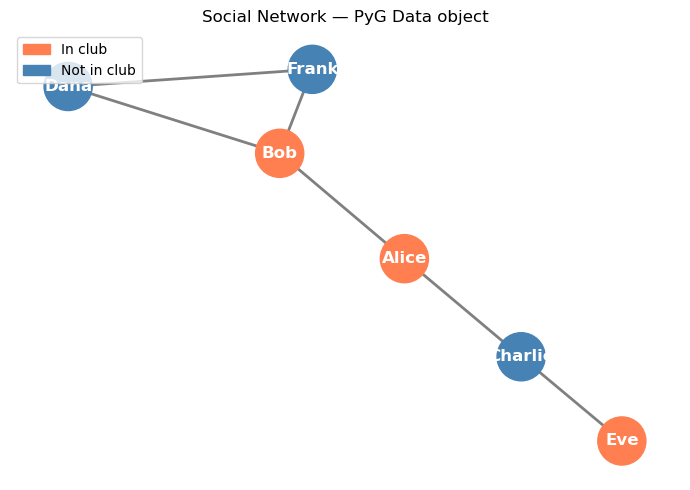

In [8]:
# Visualize the PyG graph
nx_graph = to_networkx(data, to_undirected=True)
names = ['Alice', 'Bob', 'Charlie', 'Dana', 'Eve', 'Frank']
node_colors = ['coral' if y == 1 else 'steelblue' for y in data.y.tolist()]

fig, ax = plt.subplots(figsize=(7, 5))
pos = nx.spring_layout(nx_graph, seed=42)
nx.draw(nx_graph, pos, ax=ax, with_labels=True,
        labels={i: names[i] for i in range(num_nodes)},
        node_color=node_colors, node_size=1200,
        font_color='white', font_weight='bold',
        edge_color='gray', width=2)

# Legend
from matplotlib.patches import Patch
legend = [Patch(color='coral', label='In club'),
          Patch(color='steelblue', label='Not in club')]
ax.legend(handles=legend, loc='upper left')
ax.set_title('Social Network — PyG Data object')
plt.tight_layout()
plt.show()

---
## 6. Loading Real Graph Datasets

PyG ships with many benchmark datasets. Let's look at the famous **Karate Club** graph — a small 34-node social network that will appear in later notebooks.

Dataset: KarateClub()
Num graphs: 1
Num features: 34
Num classes: 4

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])

Unique communities: tensor([0, 1, 2, 3])


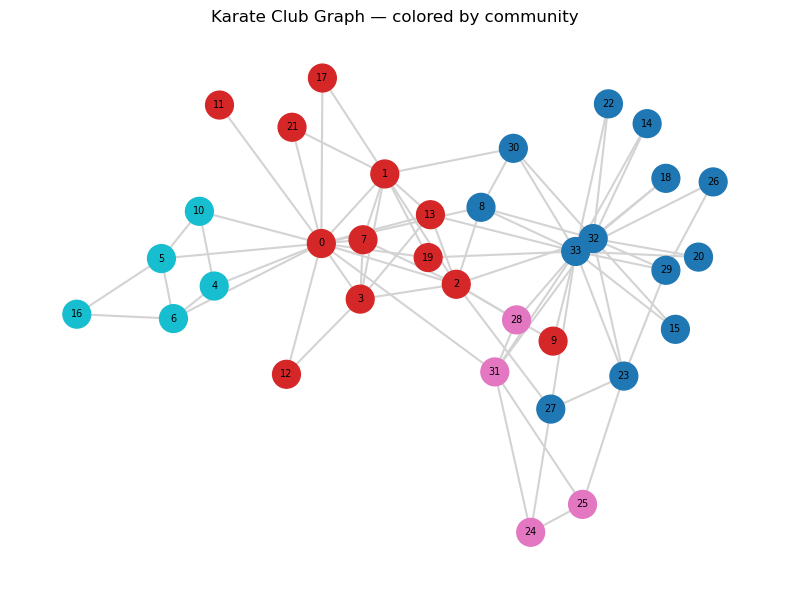

In [15]:
from torch_geometric.datasets import KarateClub

dataset = KarateClub()
data = dataset[0]  # single graph

print(f'Dataset: {dataset}')
print(f'Num graphs: {len(dataset)}')
print(f'Num features: {dataset.num_features}')
print(f'Num classes: {dataset.num_classes}')
print()
print(data)
print()
print(f'Unique communities: {data.y.unique()}')

# Visualize by community
nx_g = to_networkx(data, to_undirected=True)
colors = cm.tab10(data.y.numpy() / data.y.max().item())

fig, ax = plt.subplots(figsize=(8, 6))
pos = nx.spring_layout(nx_g, seed=7)
nx.draw(nx_g, pos, ax=ax, node_color=colors, node_size=400,
        edge_color='lightgray', width=1.5, with_labels=True,
        font_size=7)
ax.set_title('Karate Club Graph — colored by community')
plt.tight_layout()
plt.show()

---
## 7. Key Graph Properties Cheat Sheet

In [16]:
# Reload original G for demos
G = nx.karate_club_graph()

props = {
    'Nodes': G.number_of_nodes(),
    'Edges': G.number_of_edges(),
    'Avg degree': round(sum(dict(G.degree()).values()) / G.number_of_nodes(), 2),
    'Density': round(nx.density(G), 4),
    'Is connected': nx.is_connected(G),
    'Diameter': nx.diameter(G),
    'Avg clustering coeff': round(nx.average_clustering(G), 4),
    'Avg shortest path': round(nx.average_shortest_path_length(G), 4),
}

print('=== Karate Club Graph Properties ===')
for k, v in props.items():
    print(f'  {k:<30} {v}')

=== Karate Club Graph Properties ===
  Nodes                          34
  Edges                          78
  Avg degree                     4.59
  Density                        0.139
  Is connected                   True
  Diameter                       5
  Avg clustering coeff           0.5706
  Avg shortest path              2.4082


---
# MINI-PROJECT 1: Build and Analyze Your Own Graph

**Task:** Build a graph representing a real-world scenario of your choice (a friend group, a city's subway system, a small molecule, etc.) and analyze it.

**Requirements:**
1. At least 8 nodes and 10 edges
2. Nodes must have at least 2 features
3. Create a valid PyG `Data` object
4. Compute and print: degree distribution, average clustering coefficient, diameter
5. Visualize the graph with node features reflected in colors or sizes
6. Find the most central node (highest degree centrality)

**Stretch goal:** Make it a directed weighted graph with edge features.

---
Fill in the skeleton below:

Data(x=[4, 2], edge_index=[2, 20], y=[4])
Nodes: 4, Edges: 20
Degrees: [3, 2, 3, 2]


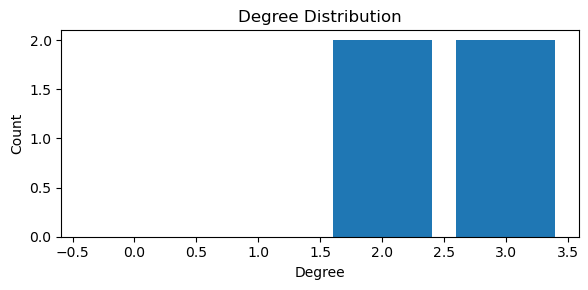

Average clustering coefficient: 0.8333
Diameter: 2
Most central node: 0 (Host-1)


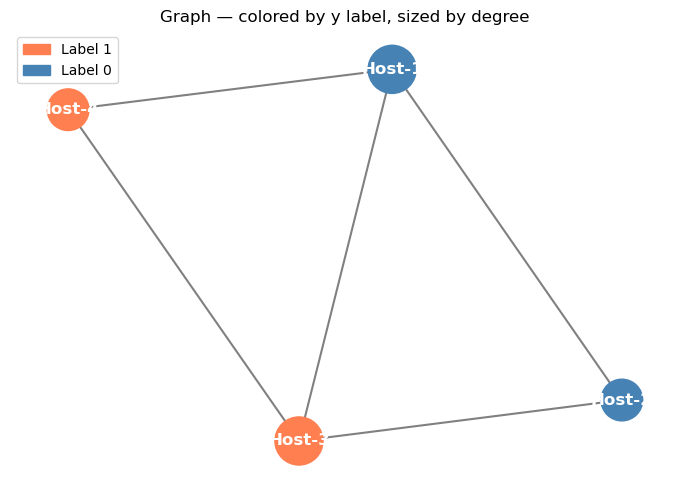

In [18]:
# MINI-PROJECT SKELETON — fill in the TODOs

import torch
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.utils import to_networkx
from matplotlib.patches import Patch

# ---------------------------------------------------------------
# TODO 1: Define your nodes and their features
# Example: nodes = ['A', 'B', 'C', ...]
# features: pick 2+ meaningful numeric features per node
# ---------------------------------------------------------------

node_names = []  # e.g., ['Alice', 'Bob', ...]

# x: shape (num_nodes, num_features)
node_names = ['Host-1', 'Host-2', 'Host-3', 'Host-4']

# Features: [ip_last_octet, temperature]
# IPs: 172.16.0.1 -> last octet 1, etc.
x = torch.tensor([
    [1, 32.1], # Node 0: IP and temperature
    [2, 28.5], # Node 1: IP and temperature
    [3, 45.0],  # Node 2: IP and temperature
    [4, 38.2], # Node 3: IP and temperature
])

# ---------------------------------------------------------------
# TODO 2: Define your edges
# Format: list of (src, dst) tuples — use node indices
# For undirected: you'll need both (i,j) and (j,i)
# ---------------------------------------------------------------

edges = [
    (0,1), (1,0), (1,2), (2,1), (0,2), (2,0), (2,3), (3,2), (0,3), (3,0)
]  # e.g., [(0, 1), (1, 2), ...]

src = [e[0] for e in edges] + [e[1] for e in edges]
dst = [e[1] for e in edges] + [e[0] for e in edges]
edge_index = torch.tensor([src, dst], dtype=torch.long)

# ---------------------------------------------------------------
# TODO 3: Define node labels (e.g., categories, groups)
# ---------------------------------------------------------------

y = torch.tensor([0, 0, 1, 1], dtype=torch.long)

# ---------------------------------------------------------------
# TODO 4: Create the PyG Data object and print its summary
# ---------------------------------------------------------------

data = Data(x=x, edge_index=edge_index, y=y)
print(data)
print(f'Nodes: {data.num_nodes}, Edges: {data.num_edges}')

# ---------------------------------------------------------------
# TODO 5: Build a NetworkX graph from your Data object and compute stats
# ---------------------------------------------------------------
# Build NetworkX graph and compute stats
nx_g = to_networkx(data, to_undirected=True)

# Degree distribution
degrees = [d for _, d in nx_g.degree()]
print('Degrees:', degrees)
plt.figure(figsize=(6,3))
plt.hist(degrees, bins=range(max(degrees)+2), align='left', rwidth=0.8)
plt.xlabel('Degree'); plt.ylabel('Count'); plt.title('Degree Distribution')
plt.tight_layout()
plt.show()

# Clustering coefficient
avg_clust = nx.average_clustering(nx_g)
print(f'Average clustering coefficient: {avg_clust:.4f}')

# Diameter (handle disconnected graphs)
if nx.is_connected(nx_g):
    diam = nx.diameter(nx_g)
else:
    diam = max(nx.diameter(nx_g.subgraph(c)) for c in nx.connected_components(nx_g))
print(f'Diameter: {diam}')

# Most central node (degree centrality)
centrality = nx.degree_centrality(nx_g)
most_central = max(centrality, key=centrality.get)
name = node_names[most_central] if most_central < len(node_names) else str(most_central)
print(f'Most central node: {most_central} ({name})')

# Visualization: color by label y, size by degree
pos = nx.spring_layout(nx_g, seed=42)
node_colors = ['coral' if int(v) == 1 else 'steelblue' for v in data.y.tolist()]
node_sizes = [d * 300 + 300 for d in degrees]  # scale for visibility

fig, ax = plt.subplots(figsize=(7,5))
nx.draw(nx_g, pos, ax=ax, with_labels=True,
        labels={i: node_names[i] if i < len(node_names) else i for i in nx_g.nodes()},
        node_color=node_colors, node_size=node_sizes,
        font_color='white', font_weight='bold', edge_color='gray', width=1.5)

legend = [Patch(color='coral', label='Label 1'), Patch(color='steelblue', label='Label 0')]
ax.legend(handles=legend, loc='upper left')
ax.set_title('Graph — colored by y label, sized by degree')
plt.tight_layout()
plt.show()

### Hints

<details>
<summary>Hint 1 — Degree distribution</summary>

```python
degrees = [d for _, d in nx_g.degree()]
plt.hist(degrees, bins=range(max(degrees)+2))
plt.xlabel('Degree'); plt.ylabel('Count')
plt.title('Degree Distribution')
plt.show()
```
</details>

<details>
<summary>Hint 2 — Most central node</summary>

```python
centrality = nx.degree_centrality(nx_g)
most_central = max(centrality, key=centrality.get)
print(f'Most central: node {most_central} ({node_names[most_central]})')
```
</details>

<details>
<summary>Hint 3 — Visualize with feature-based node sizes</summary>

```python
node_sizes = [data.x[i, 0].item() * 1000 + 200 for i in range(data.num_nodes)]
nx.draw(nx_g, pos, node_size=node_sizes, ...)
```
</details>

---
## What's Next?

In **Notebook 2**, we'll answer the key question: *how do neural networks actually run on these graph structures?* We'll derive and implement the Graph Convolutional Network (GCN) — the "ResNet of GNNs" — from scratch.